In [ ]:
%load_ext lab_black
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [ ]:
import os
import pickle
import numpy as np
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import matplotlib.pyplot as plt
import numpy as np
import pickle


def create_hierarchy():
    hierarchy = {}
    fmin_fmax = [(1, 4), (4, 8), (8, 12), (13, 30), (30, 50), (1, 120)]
    conditions = range(1, 7)
    patients = range(2, 22)
    states = ["pre", "during", "post"]

    for fmin, fmax in fmin_fmax:
        filter_key = f"{fmin}_{fmax}"
        hierarchy[filter_key] = {}
        for condition in conditions:
            hierarchy[filter_key][condition] = {}
            for patient in patients:
                hierarchy[filter_key][condition][patient] = {}
                folder = f"D:\\neuro-closeloop-project\\vielight_close_loop\\notebooks\\filters\\{filter_key}\\conditions\\{condition}\\results\\{patient}"
                if os.path.exists(folder) and os.listdir(folder):
                    for state in states:
                        pickle_file = os.path.join(
                            folder, f"{patient}_{state}_connectivity.pkl"
                        )
                        if os.path.exists(pickle_file):
                            with open(pickle_file, "rb") as f:
                                hierarchy[filter_key][condition][patient][state] = (
                                    pickle.load(f)
                                )
                        else:
                            print(f"Missing pickle file: {pickle_file}")
                            hierarchy[filter_key][condition][patient][state] = None
                else:
                    print(f"Empty or non-existent folder: {folder}")
                    for state in states:
                        hierarchy[filter_key][condition][patient][state] = None

    return hierarchy


In [ ]:
# Usage
hierarchy = create_hierarchy()
print(hierarchy.keys())
print(hierarchy["1_120"].keys())
print(hierarchy["1_120"][1].keys())
print(hierarchy["1_120"][1][2].keys())
print(hierarchy["1_120"][1][2]["pre"])


# Graph Method

In [ ]:
# Cell 1: Imports and Setup
import os
import pickle
import numpy as np
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import logging
from datetime import datetime

# Configure logging with timestamp and file output
log_dir = "logs"
os.makedirs(log_dir, exist_ok=True)
log_file = os.path.join(
    log_dir, f'analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.FileHandler(log_file), logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

import numpy as np
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def extract_graph_features(connectivity_matrix):
    """Extract graph theoretical features from connectivity matrix"""
    # Create graph from connectivity matrix
    G = nx.from_numpy_array(np.abs(connectivity_matrix))

    features = {}

    # Node-level metrics
    features["degree_centrality"] = list(nx.degree_centrality(G).values())
    features["betweenness_centrality"] = list(nx.betweenness_centrality(G).values())
    features["eigenvector_centrality"] = list(
        nx.eigenvector_centrality(G, max_iter=1000).values()
    )

    # Network-level metrics
    features["clustering_coefficient"] = nx.average_clustering(G)
    features["average_path_length"] = nx.average_shortest_path_length(G)
    features["modularity"] = nx.community.modularity(
        G, nx.community.greedy_modularity_communities(G)
    )

    return features


def process_patient_data(data_structure):
    """Process full patient dataset and extract features"""
    all_features = []
    labels = []

    for freq_band in data_structure:
        for condition in freq_band:
            for patient in condition:
                for phase, matrix in enumerate(patient):  # pre, during, post
                    features = extract_graph_features(matrix)

                    # Flatten features into single vector
                    feature_vector = []
                    for metric in features.values():
                        if isinstance(metric, list):
                            feature_vector.extend(metric)
                        else:
                            feature_vector.append(metric)

                    all_features.append(feature_vector)
                    labels.append(phase)  # 0: pre, 1: during, 2: post

    return np.array(all_features), np.array(labels)


def train_classifier(features, labels):
    """Train and evaluate Random Forest classifier"""
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    clf = RandomForestClassifier(n_estimators=100, random_state=42)

    # Perform cross-validation
    scores = cross_val_score(clf, features_scaled, labels, cv=5)

    # Train on full dataset for feature importance
    clf.fit(features_scaled, labels)

    return clf, scores


def analyze_feature_importance(clf, feature_names):
    """Analyze which graph metrics are most discriminative"""
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]

    return [(feature_names[i], importances[i]) for i in indices]


In [ ]:
def process_band_data(hierarchy, freq_band):
    logger.info(f"Processing frequency band: {freq_band}")
    all_features = []
    labels = []
    metadata = []

    for condition in hierarchy[freq_band]:
        # Initialize condition-level label counts
        condition_labels = []

        for patient in hierarchy[freq_band][condition]:
            patient_data = hierarchy[freq_band][condition][patient]
            if not all(patient_data.values()):
                logger.warning(
                    f"Skipping incomplete data - Freq: {freq_band}, Condition: {condition}, Patient: {patient}"
                )
                continue

            for phase, state in enumerate(["pre", "during", "post"]):
                try:
                    features = extract_graph_features(
                        patient_data[state].get_data("dense").squeeze()
                    )
                    if features:
                        feature_vector = []
                        for metric in features.values():
                            if isinstance(metric, list):
                                feature_vector.extend(metric)
                            else:
                                feature_vector.append(metric)
                        all_features.append(feature_vector)
                        labels.append(phase)
                        condition_labels.append(phase)
                        metadata.append(
                            {
                                "freq_band": freq_band,
                                "condition": condition,
                                "patient": patient,
                                "phase": state,
                            }
                        )
                except Exception as e:
                    logger.error(
                        f"Error processing - Freq: {freq_band}, Condition: {condition}, Patient: {patient}, Phase: {state}"
                    )
                    logger.error(f"Error details: {str(e)}")

        # Log condition-level label distribution
        if condition_labels:
            unique, counts = np.unique(condition_labels, return_counts=True)
            dist = dict(zip(unique, counts))
            logger.info(
                f"Label distribution for {freq_band}, Condition {condition}: {dist}"
            )

    # Log overall label distribution
    if labels:
        unique, counts = np.unique(labels, return_counts=True)
        dist = dict(zip(unique, counts))
        logger.info(f"Overall label distribution for {freq_band}: {dist}")

    return np.array(all_features), np.array(labels), metadata


In [ ]:
# Cell 3: Main Analysis Pipeline
def run_analysis_pipeline(hierarchy):
    logger.info("Starting analysis pipeline")
    results = {}

    for freq_band in hierarchy.keys():
        logger.info(f"\n{'='*50}\nProcessing {freq_band}\n{'='*50}")

        try:
            # Process data
            features, labels, metadata = process_band_data(hierarchy, freq_band)

            if len(features) == 0:
                logger.warning(f"No valid features for {freq_band}")
                continue

            # Train and evaluate
            clf, scores = train_classifier(features, labels)

            # Generate feature names
            feature_names = []
            metrics = [
                "degree_centrality",
                "betweenness_centrality",
                "eigenvector_centrality",
            ]
            for metric in metrics:
                feature_names.extend(
                    [f"{metric}_node_{i}" for i in range(features.shape[1] // 3)]
                )
            feature_names.extend(
                ["clustering_coefficient", "average_path_length", "modularity"]
            )

            # Analyze feature importance
            importance = analyze_feature_importance(clf, feature_names)

            # Store results
            results[freq_band] = {
                "scores": scores,
                "mean_score": scores.mean(),
                "std_score": scores.std(),
                "feature_importance": importance,
                "metadata": metadata,
            }

            logger.info(f"Results for {freq_band}:")
            logger.info(
                f"Classification accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})"
            )

        except Exception as e:
            logger.error(f"Error processing frequency band {freq_band}")
            logger.error(f"Error details: {str(e)}")
            continue

    return results


In [ ]:
# Cell 4: Execute Pipeline
try:
    # Load data
    logger.info("Loading data hierarchy")
    hierarchy = create_hierarchy()

    # Run analysis
    results = run_analysis_pipeline(hierarchy)

    # Save results
    output_dir = "analysis_results"
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(
        output_dir,
        f"phase_discrimination_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl",
    )

    with open(output_file, "wb") as f:
        pickle.dump(results, f)
    logger.info(f"Results saved to {output_file}")

except Exception as e:
    logger.critical("Pipeline failed")
    logger.critical(f"Error details: {str(e)}")


In [ ]:
def visualize_features(hierarchy, freq_band, condition, patient):
    """
    Visualize graph features extracted from connectivity matrices for a single patient.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    phases = ["pre", "during", "post"]
    patient_data = hierarchy[freq_band][condition][patient]

    # Extract features for each phase
    features_by_phase = {}
    for phase in phases:
        conn_matrix = patient_data[phase].get_data("dense").squeeze()
        features = extract_graph_features(conn_matrix)
        features_by_phase[phase] = features

    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(
        f"Graph Features - Freq: {freq_band}, Condition: {condition}, Patient: {patient}"
    )

    # Plot connectivity matrices
    for i, phase in enumerate(phases):
        conn_matrix = patient_data[phase].get_data("dense").squeeze()
        ax = plt.subplot(2, 3, i + 1)
        sns.heatmap(conn_matrix, ax=ax, cmap="coolwarm", center=0)
        ax.set_title(f"{phase.capitalize()} Phase Connectivity")

    # Plot node metrics
    metrics_ax = plt.subplot(2, 2, 3)
    x = np.arange(len(phases))
    width = 0.25

    for i, metric in enumerate(
        ["degree_centrality", "betweenness_centrality", "eigenvector_centrality"]
    ):
        values = [np.mean(features_by_phase[phase][metric]) for phase in phases]
        metrics_ax.bar(x + i * width, values, width, label=metric)

    metrics_ax.set_xticks(x + width)
    metrics_ax.set_xticklabels(phases)
    metrics_ax.set_title("Node-level Metrics")
    metrics_ax.legend()

    # Plot global metrics
    global_ax = plt.subplot(2, 2, 4)
    global_metrics = ["clustering_coefficient", "average_path_length", "modularity"]

    for i, metric in enumerate(global_metrics):
        values = [features_by_phase[phase][metric] for phase in phases]
        global_ax.bar(x + i * width, values, width, label=metric)

    global_ax.set_xticks(x + width)
    global_ax.set_xticklabels(phases)
    global_ax.set_title("Network-level Metrics")
    global_ax.legend()

    plt.tight_layout()
    return fig


In [ ]:
# Plot features for a specific patient
fig = visualize_features(hierarchy, "1_4", 1, 3)
plt.savefig("features_visualization.png")
plt.close()


# Simple Method

In [ ]:
def process_connectivity_data(hierarchy, freq_band):
    features = []
    labels = []

    for condition in hierarchy[freq_band]:
        for patient in hierarchy[freq_band][condition]:
            patient_data = hierarchy[freq_band][condition][patient]

            if not all(patient_data.values()):
                continue

            for phase, state in enumerate(["pre", "during", "post"]):
                try:
                    conn_matrix = patient_data[state].get_data("dense").squeeze()

                    # Remove rows/columns with NaN values
                    mask = ~np.isnan(conn_matrix).any(axis=1)
                    clean_matrix = conn_matrix[mask][:, mask]

                    if clean_matrix.size > 0:
                        # Take lower triangle only (excluding diagonal)
                        lower_tri = clean_matrix[
                            np.tril_indices_from(clean_matrix, k=-1)
                        ]
                        features.append(lower_tri)
                        labels.append(phase)

                except Exception as e:
                    print(
                        f"Error processing {freq_band}-{condition}-{patient}-{state}: {e}"
                    )

    return np.array(features), np.array(labels)


def analyze_feature_importance(X, y, freq_band):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5)

    # Fit on full data to get feature importance
    clf.fit(X, y)

    # Get indices of top features
    importances = clf.feature_importances_
    top_indices = np.argsort(importances)[-10:]  # Top 10 features

    # Convert indices back to matrix coordinates
    n = 60

    def index_to_coords(k):
        # Convert from upper triangular index to matrix coordinates
        i = int(n - 2 - np.floor(np.sqrt(-8 * k + 4 * n * (n - 1) - 7) / 2.0 - 0.5))
        j = int(k + i + 1 - n * (n - 1) / 2 + (n - i) * ((n - i) - 1) / 2)
        return i, j

    important_connections = [index_to_coords(idx) for idx in top_indices]

    logger.info(f"\nResults for {freq_band}:")
    logger.info(f"Accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")
    logger.info("Top 10 important connections (node pairs):")
    for idx, (i, j) in enumerate(important_connections, 1):
        logger.info(f"{idx}. Nodes {i}-{j}: {importances[top_indices[-idx]]:.4f}")

    return scores, important_connections, importances


In [ ]:
def visualize_connectivity_importance(
    hierarchy, freq_band, important_connections, importances, channels
):
    """
    Visualize important connections in connectivity matrix and their importance scores.

    Parameters:
    -----------
    hierarchy : dict
        Nested dictionary containing connectivity data
    freq_band : str
        Frequency band to analyze
    important_connections : list of tuples
        List of (i,j) pairs indicating important connections
    importances : array-like
        Importance scores for each connection
    channels : list
        List of channel names
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create importance matrix
    importance_matrix = np.zeros((60, 60))
    for idx, (i, j) in enumerate(important_connections):
        importance_matrix[i, j] = importances[idx]
        importance_matrix[j, i] = importances[idx]

    # Calculate average connectivity
    avg_conn = np.zeros((60, 60))
    count = 0
    for condition in hierarchy[freq_band]:
        for patient in hierarchy[freq_band][condition]:
            for state in ["pre", "during", "post"]:
                try:
                    conn = (
                        hierarchy[freq_band][condition][patient][state]
                        .get_data("dense")
                        .squeeze()
                    )
                    avg_conn += conn
                    count += 1
                except:
                    continue
    avg_conn /= count

    # Create figure with larger size and adjust spacing
    fig = plt.figure(figsize=(20, 8))
    gs = plt.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1])

    # Plot average connectivity matrix
    sns.heatmap(
        avg_conn,
        ax=ax1,
        cmap="coolwarm",
        center=0,
        xticklabels=channels,
        yticklabels=channels,
        cbar_kws={"shrink": 0.5},
    )
    ax1.set_title("Average Connectivity", pad=20)

    # Rotate labels for better readability
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
    ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

    # Plot importance matrix
    mask = importance_matrix == 0
    sns.heatmap(
        importance_matrix,
        ax=ax2,
        cmap="viridis",
        mask=mask,
        xticklabels=channels,
        yticklabels=channels,
        cbar_kws={"shrink": 0.5},
    )
    ax2.set_title("Feature Importance", pad=20)

    # Rotate labels for better readability
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

    plt.suptitle(f"Connectivity Analysis - {freq_band} Hz", y=1.05)

    return fig


def plot_accuracies(results):
    """
    Plot classification accuracies across frequency bands with error bars.

    Args:
        results (dict): Dictionary with band accuracies {band: {'accuracy': acc, 'std': std}}
    """
    import matplotlib.pyplot as plt
    import numpy as np

    bands = list(results.keys())
    accuracies = [results[band]["accuracy"] for band in bands]
    errors = [results[band]["std"] * 2 for band in bands]  # 2 std for 95% CI

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(bands, accuracies, yerr=errors, capsize=5)

    ax.set_ylabel("Classification Accuracy")
    ax.set_xlabel("Frequency Bands (Hz)")
    ax.set_title("Phase Classification Performance Across Frequency Bands")
    ax.grid(True, alpha=0.3, axis="y")

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
        )

    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


def get_channels():
    return [
        "AF3",
        "F1",
        "F3",
        "F5",
        "F7",
        "FC1",
        "FC3",
        "FC5",
        "FCZ",
        "FP1",
        "FPZ",
        "FT7",
        "FZ",
        "C1",
        "C3",
        "C5",
        "CZ",
        "T7",
        "TP7",
        "CP1",
        "CP3",
        "CP5",
        "P1",
        "P3",
        "P5",
        "P7",
        "PO3",
        "PO5",
        "PO7",
        "O1",
        "POZ",
        "OZ",
        "PZ",
        "CPZ",
        "TP8",
        "T8",
        "PO8",
        "PO6",
        "PO4",
        "O2",
        "P8",
        "P6",
        "P4",
        "P2",
        "CP6",
        "CP4",
        "CP2",
        "C6",
        "C4",
        "C2",
        "FT8",
        "FP2",
        "FC6",
        "FC4",
        "FC2",
        "F8",
        "F6",
        "F4",
        "F2",
        "AF4",
    ]


all_scores = {}

# Add to analysis pipeline:
for freq_band in hierarchy:
    X, y = process_connectivity_data(hierarchy, freq_band)
    scores, important_connections, importances = analyze_feature_importance(
        X, y, freq_band
    )
    # Store results
    all_scores[freq_band] = {"accuracy": scores.mean(), "std": scores.std()}

    fig = visualize_connectivity_importance(
        hierarchy, freq_band, important_connections, importances, get_channels()
    )

    plt.savefig(f"connectivity_importance_{freq_band}.png")
    plt.close()

# After processing all bands
plot_accuracies(all_scores)


# Circular Visualization

In [ ]:
import os
import pickle
import numpy as np
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import matplotlib.pyplot as plt
import numpy as np
import pickle


def get_channel_5_colors():
    return [
        "AF3",
        "F1",
        "F3",
        "F5",
        "F7",
        "FC1",
        "FC3",
        "FC5",
        "FCZ",
        "FP1",
        "FPZ",
        "FT7",
        "FZ",
        "C1",
        "C3",
        "C5",
        "CZ",
        "T7",
        "TP7",
        "CP1",
        "CP3",
        "CP5",
        "P1",
        "P3",
        "P5",
        "P7",
        "PO3",
        "PO5",
        "PO7",
        "O1",
        "POZ",
        "OZ",
        "PZ",
        "CPZ",
        "TP8",
        "T8",
        "PO8",
        "PO6",
        "PO4",
        "O2",
        "P8",
        "P6",
        "P4",
        "P2",
        "CP6",
        "CP4",
        "CP2",
        "C6",
        "C4",
        "C2",
        "FT8",
        "FP2",
        "FC6",
        "FC4",
        "FC2",
        "F8",
        "F6",
        "F4",
        "F2",
        "AF4",
    ]


def assign_channel_5_colors():
    red = (0.458, 0.0, 0.0, 1.0)
    green = (0.0, 1.0, 0.0, 1.0)
    blue = (0.0, 0.0, 0.999, 1.0)
    purple = (0.5, 0.0, 0.5, 1.0)
    orange = (1.0, 0.647, 0.0, 1.0)
    black = (0.0, 0.0, 0.0, 1.0)

    # New color for separators
    channel_color = {
        # Frontal (Red)
        "AF3": red,
        "AF4": red,
        "F1": red,
        "F2": red,
        "F3": red,
        "F4": red,
        "F5": red,
        "F6": red,
        "F7": red,
        "F8": red,
        "FC1": red,
        "FC2": red,
        "FC3": red,
        "FC4": red,
        "FC5": red,
        "FC6": red,
        "FCZ": red,
        "FP1": red,
        "FP2": red,
        "FPZ": red,
        "FT7": red,
        "FT8": red,
        "FZ": red,
        # Central (Green)
        "C1": green,
        "C2": green,
        "C3": green,
        "C4": green,
        "C5": green,
        "C6": green,
        "CZ": green,
        # Parietal (Blue)
        "CP1": blue,
        "CP2": blue,
        "CP3": blue,
        "CP4": blue,
        "CP5": blue,
        "CP6": blue,
        "CPZ": blue,
        "P1": blue,
        "P2": blue,
        "P3": blue,
        "P4": blue,
        "P5": blue,
        "P6": blue,
        "P7": blue,
        "P8": blue,
        "PZ": blue,
        # Occipital (Purple)
        "O1": purple,
        "O2": purple,
        "OZ": purple,
        "PO3": purple,
        "PO4": purple,
        "PO5": purple,
        "PO6": purple,
        "PO7": purple,
        "PO8": purple,
        "POZ": purple,
        # Temporal (Orange)
        "T7": orange,
        "T8": orange,
        "TP7": orange,
        "TP8": orange,
    }

    return channel_color


def prepare_circular_layout(label_names):
    """
    Prepare the circular layout for the connectivity plot.

    Args:
    label_names (list): List of channel names.

    Returns:
    tuple: Node angles and node order for the circular layout.
    """
    n_channels = len(label_names)
    node_angles = circular_layout(
        label_names,
        label_names,
        start_pos=90,
        group_boundaries=[0, len(label_names) // 2],
    )
    node_order = label_names
    return node_angles, node_order


def get_circular_plot_requirements(label_names):
    """
    Get the requirements for a circular connectivity plot with left channels first.

    Args:
    label_names (list): List of channel names.

    Returns:
    tuple: Node angles, node order, and node colors for the circular plot.
    """

    sorted_channels = get_channel_5_colors()

    # Assign colors to channels
    # channel_color = assign_channel_colors(channels_side, left_color, right_color)
    channel_color = assign_channel_5_colors()

    # Prepare circular layout with sorted channels
    node_angles, _ = prepare_circular_layout(list(channel_color.keys()))

    # Get node colors in the same order as sorted_channels
    node_colors = [channel_color[channel] for channel in sorted_channels]

    return node_angles, sorted_channels, node_colors


def plot_circular_connectivity(
    connectivity,
    stage,
    label_names,
    node_angles,
    node_colors,
    method="wpli",
    is_save=False,
    n_lines=20,
    figsize=(8, 8),
):
    """
    Plot circular connectivity diagram.

    Args:
    connectivity (mne.Connectivity): The connectivity object.
    stage (str): The stage of the experiment (e.g., 'pre', 'during', 'post').
    label_names (list): List of channel names.
    node_angles (dict): Dictionary of node angles for the circular plot.
    node_colors (list): List of colors for each node.
    method (str, optional): Connectivity method used. Defaults to "wpli".
    is_save (bool, optional): Whether to save the figure. Defaults to False.
    n_lines (int, optional): Number of connections to draw. Defaults to 20.
    figsize (tuple, optional): Figure size. Defaults to (8, 8).

    Returns:
    matplotlib.figure.Figure: The created figure.
    """
    # Create figure
    fig, ax = plt.subplots(
        figsize=figsize, facecolor="black", subplot_kw=dict(polar=True)
    )

    if not isinstance(connectivity, np.ndarray):
        connectivity = connectivity.get_data("dense")[:, :, 0]

    if connectivity.ndim == 3:
        connectivity = connectivity[:, :, 0]

    print(f"{len(node_angles) = }")
    print(f"{len(node_colors) = }")

    # Plot connectivity circle
    plot_connectivity_circle(
        con=connectivity,
        node_names=label_names,
        n_lines=n_lines,
        node_angles=node_angles,
        node_colors=node_colors,
        title=f"All-to-All Connectivity {stage} stimuli Condition ({method})",
        ax=ax,
    )

    # Adjust layout
    fig.tight_layout()

    # Save figure if requested
    if is_save:
        filename = f"{method}_{stage}.png"
        fig.savefig(filename, dpi=300)
        print(f"Figure saved as {filename}")

    return fig


def prepare_plot_data(hierarchy, freq_band, condition, patient, state):
    """
    Extract data from the hierarchy and prepare for plotting.

    Args:
    hierarchy (dict): The hierarchical data structure
    freq_band (str): Frequency band key (e.g., '1_4', '4_8', etc.)
    condition (int): Condition number (1-6)
    patient (int): Patient number (2-21)
    state (str): State ('pre', 'during', 'post')

    Returns:
    tuple: connectivity_data, node_angles, node_order, node_colors
    """
    # Extract SpectralConnectivity object
    spectral_conn = hierarchy[freq_band][condition][patient][state]

    if spectral_conn is None:
        raise ValueError(
            f"No data for {freq_band}, condition {condition}, patient {patient}, state {state}"
        )

    # Extract connectivity data
    connectivity_data = spectral_conn.get_data(output="dense")[
        :, :, 0
    ]  # Assuming first frequency

    # Get channel names
    channel_names = get_channel_5_colors()

    # Prepare circular layout
    node_angles, node_order, node_colors = get_circular_plot_requirements(channel_names)

    return connectivity_data, node_angles, node_order, node_colors


In [ ]:
def plot_importance_circular(importance_matrix, threshold=0.01):
    """
    Plot circular connectivity diagram for feature importance.

    Args:
        importance_matrix (np.ndarray): Matrix of feature importances (60x60)
        threshold (float): Minimum importance value to show
    """
    # Create mask for non-zero values above threshold
    mask = importance_matrix > threshold

    # Get channel information
    channel_names = get_channel_5_colors()
    node_angles, node_order, node_colors = get_circular_plot_requirements(channel_names)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

    # Plot connectivity circle with masked data
    plot_connectivity_circle(
        con=np.where(mask, importance_matrix, 0),
        node_names=node_order,
        n_lines=None,  # Show all connections above threshold
        node_angles=node_angles,
        node_colors=node_colors,
        title="Feature Importance Connectivity",
        ax=ax,
    )

    plt.tight_layout()
    return fig


def plot_importance_by_frequency(hierarchy, all_importances):
    """Plot importance matrices for each frequency band."""
    freq_bands = list(all_importances.keys())
    n_bands = len(freq_bands)

    if n_bands == 1:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))
        axes = [ax]
    else:
        fig, axes = plt.subplots(
            1, n_bands, figsize=(5 * n_bands, 5), subplot_kw=dict(polar=True)
        )

    channel_names = get_channel_5_colors()
    node_angles, node_order, node_colors = get_circular_plot_requirements(channel_names)

    for idx, freq_band in enumerate(freq_bands):
        importance_matrix = all_importances[freq_band]
        mask = importance_matrix > np.percentile(importance_matrix, 90)  # Top 10%

        plot_connectivity_circle(
            con=np.where(mask, importance_matrix, 0),
            node_names=node_order,
            n_lines=None,
            node_angles=node_angles,
            node_colors=node_colors,
            title=f"{freq_band} Hz",
            ax=axes[idx],
            show=False,
        )

        if idx != 0 and n_bands > 1:  # Remove colorbar except for first plot
            axes[idx].collections[-1].colorbar.remove()

    plt.tight_layout()
    return fig


# Usage example:
def visualize_all_importance(hierarchy, freq_band, important_connections, importances):
    importance_matrix = np.zeros((60, 60))
    for idx, (i, j) in enumerate(important_connections):
        # Only fill lower triangular part
        if i > j:
            importance_matrix[i, j] = 1 if importances[idx] > 0 else 0
        else:
            importance_matrix[j, i] = 1 if importances[idx] > 0 else 0

    all_importances = {freq_band: importance_matrix}
    fig_multi = plot_importance_by_frequency(hierarchy, all_importances)
    return None, fig_multi


2024-11-28 16:00:29,097 - INFO - 
Results for 1_4:
2024-11-28 16:00:29,098 - INFO - Accuracy: 0.352 (+/- 0.078)
2024-11-28 16:00:29,098 - INFO - Top 10 important connections (node pairs):
2024-11-28 16:00:29,098 - INFO - 1. Nodes 6-40: 0.0040
2024-11-28 16:00:29,099 - INFO - 2. Nodes 45-48: 0.0025
2024-11-28 16:00:29,099 - INFO - 3. Nodes 26-35: 0.0024
2024-11-28 16:00:29,099 - INFO - 4. Nodes 46-51: 0.0023
2024-11-28 16:00:29,100 - INFO - 5. Nodes 17-54: 0.0023
2024-11-28 16:00:29,100 - INFO - 6. Nodes 15-17: 0.0023
2024-11-28 16:00:29,100 - INFO - 7. Nodes 7-52: 0.0022
2024-11-28 16:00:29,100 - INFO - 8. Nodes 15-49: 0.0021
2024-11-28 16:00:29,101 - INFO - 9. Nodes 29-40: 0.0020
2024-11-28 16:00:29,101 - INFO - 10. Nodes 15-37: 0.0020


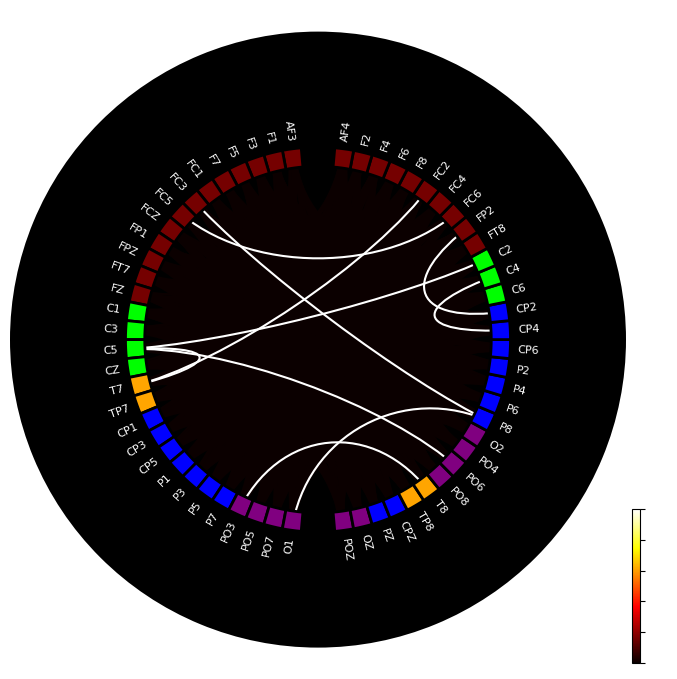


Top important connections in 1_4 Hz band:
1. FC3 - P8: 0.0017
2. CP4 - C4: 0.0004
3. PO3 - T8: 0.0004
4. CP2 - FP2: 0.0004
5. T7 - FC2: 0.0004


2024-11-28 16:00:32,093 - INFO - 
Results for 4_8:
2024-11-28 16:00:32,093 - INFO - Accuracy: 0.472 (+/- 0.079)
2024-11-28 16:00:32,094 - INFO - Top 10 important connections (node pairs):
2024-11-28 16:00:32,094 - INFO - 1. Nodes 23-26: 0.0036
2024-11-28 16:00:32,094 - INFO - 2. Nodes 9-25: 0.0029
2024-11-28 16:00:32,095 - INFO - 3. Nodes 7-20: 0.0028
2024-11-28 16:00:32,095 - INFO - 4. Nodes 25-48: 0.0027
2024-11-28 16:00:32,095 - INFO - 5. Nodes 43-51: 0.0027
2024-11-28 16:00:32,096 - INFO - 6. Nodes 9-22: 0.0024
2024-11-28 16:00:32,096 - INFO - 7. Nodes 25-31: 0.0024
2024-11-28 16:00:32,096 - INFO - 8. Nodes 42-52: 0.0022
2024-11-28 16:00:32,096 - INFO - 9. Nodes 42-49: 0.0021
2024-11-28 16:00:32,097 - INFO - 10. Nodes 42-47: 0.0021


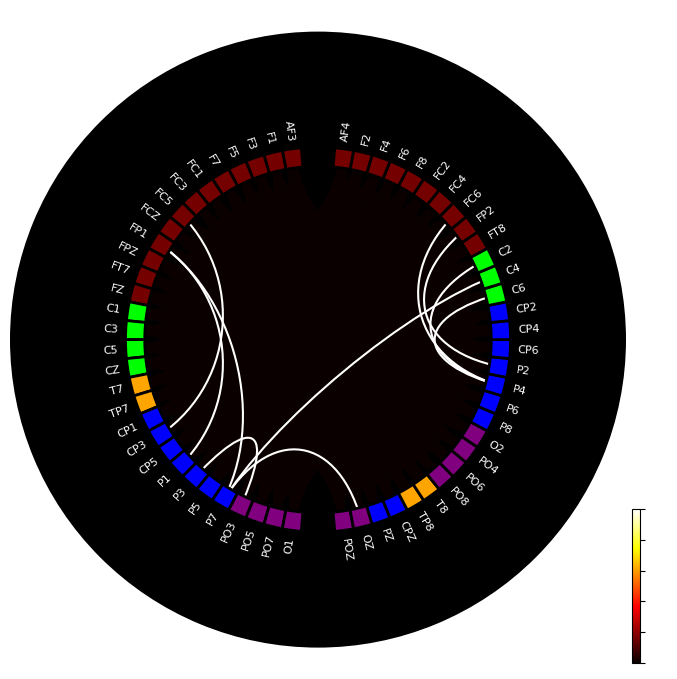


Top important connections in 4_8 Hz band:
1. P3 - PO3: 0.0005
2. FP1 - P7: 0.0001
3. FC5 - CP3: 0.0003
4. P7 - C4: 0.0006
5. P2 - FP2: 0.0005


2024-11-28 16:00:35,293 - INFO - 
Results for 8_12:
2024-11-28 16:00:35,293 - INFO - Accuracy: 0.455 (+/- 0.118)
2024-11-28 16:00:35,294 - INFO - Top 10 important connections (node pairs):
2024-11-28 16:00:35,294 - INFO - 1. Nodes 4-29: 0.0053
2024-11-28 16:00:35,294 - INFO - 2. Nodes 20-32: 0.0032
2024-11-28 16:00:35,295 - INFO - 3. Nodes 39-42: 0.0030
2024-11-28 16:00:35,295 - INFO - 4. Nodes 3-18: 0.0026
2024-11-28 16:00:35,295 - INFO - 5. Nodes 51-56: 0.0025
2024-11-28 16:00:35,295 - INFO - 6. Nodes 57-59: 0.0025
2024-11-28 16:00:35,296 - INFO - 7. Nodes 21-36: 0.0024
2024-11-28 16:00:35,296 - INFO - 8. Nodes 23-35: 0.0023
2024-11-28 16:00:35,296 - INFO - 9. Nodes 43-47: 0.0023
2024-11-28 16:00:35,296 - INFO - 10. Nodes 0-54: 0.0022


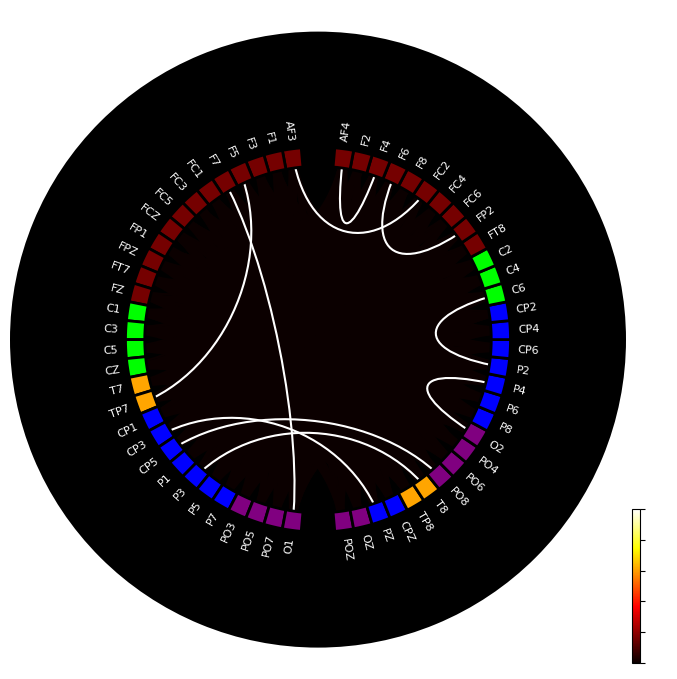


Top important connections in 8_12 Hz band:
1. F7 - O1: 0.0003
2. CP3 - PZ: 0.0001
3. O2 - P4: 0.0000
4. F5 - TP7: 0.0002
5. FP2 - F6: 0.0010


2024-11-28 16:00:38,222 - INFO - 
Results for 13_30:
2024-11-28 16:00:38,223 - INFO - Accuracy: 0.542 (+/- 0.098)
2024-11-28 16:00:38,224 - INFO - Top 10 important connections (node pairs):
2024-11-28 16:00:38,224 - INFO - 1. Nodes 1-4: 0.0037
2024-11-28 16:00:38,225 - INFO - 2. Nodes 10-50: 0.0033
2024-11-28 16:00:38,225 - INFO - 3. Nodes 35-44: 0.0033
2024-11-28 16:00:38,225 - INFO - 4. Nodes 42-49: 0.0033
2024-11-28 16:00:38,226 - INFO - 5. Nodes 25-33: 0.0033
2024-11-28 16:00:38,226 - INFO - 6. Nodes 20-40: 0.0032
2024-11-28 16:00:38,226 - INFO - 7. Nodes 9-31: 0.0032
2024-11-28 16:00:38,226 - INFO - 8. Nodes 51-54: 0.0031
2024-11-28 16:00:38,227 - INFO - 9. Nodes 37-40: 0.0031
2024-11-28 16:00:38,227 - INFO - 10. Nodes 50-58: 0.0031


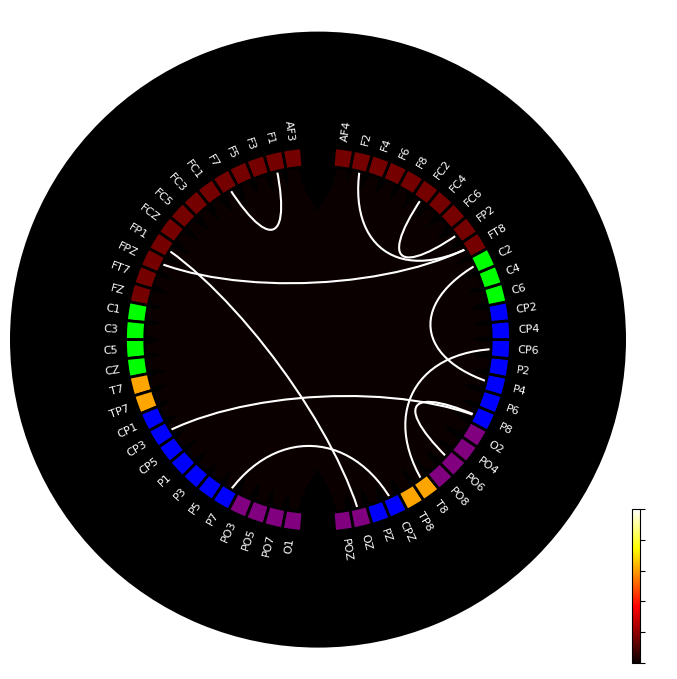


Top important connections in 13_30 Hz band:
1. F1 - F7: 0.0015
2. FPZ - FT8: 0.0008
3. T8 - CP6: 0.0010
4. P4 - C2: 0.0001
5. P7 - CPZ: 0.0001


2024-11-28 16:00:41,182 - INFO - 
Results for 30_50:
2024-11-28 16:00:41,183 - INFO - Accuracy: 0.487 (+/- 0.155)
2024-11-28 16:00:41,183 - INFO - Top 10 important connections (node pairs):
2024-11-28 16:00:41,184 - INFO - 1. Nodes 16-42: 0.0040
2024-11-28 16:00:41,184 - INFO - 2. Nodes 30-37: 0.0034
2024-11-28 16:00:41,184 - INFO - 3. Nodes 19-53: 0.0032
2024-11-28 16:00:41,185 - INFO - 4. Nodes 22-48: 0.0029
2024-11-28 16:00:41,185 - INFO - 5. Nodes 4-36: 0.0028
2024-11-28 16:00:41,185 - INFO - 6. Nodes 1-32: 0.0028
2024-11-28 16:00:41,185 - INFO - 7. Nodes 0-45: 0.0027
2024-11-28 16:00:41,186 - INFO - 8. Nodes 0-25: 0.0027
2024-11-28 16:00:41,186 - INFO - 9. Nodes 9-31: 0.0026
2024-11-28 16:00:41,186 - INFO - 10. Nodes 24-36: 0.0026


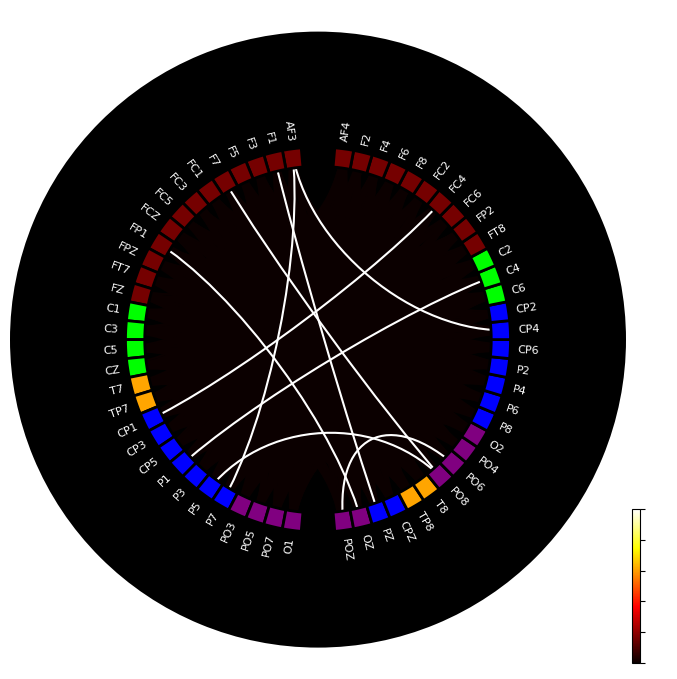


Top important connections in 30_50 Hz band:
1. CZ - P4: 0.0000
2. POZ - PO6: 0.0006
3. CP1 - FC4: 0.0011
4. P1 - C4: 0.0007
5. F7 - PO8: 0.0010


2024-11-28 16:00:44,132 - INFO - 
Results for 1_120:
2024-11-28 16:00:44,132 - INFO - Accuracy: 0.507 (+/- 0.143)
2024-11-28 16:00:44,132 - INFO - Top 10 important connections (node pairs):
2024-11-28 16:00:44,132 - INFO - 1. Nodes 16-36: 0.0042
2024-11-28 16:00:44,133 - INFO - 2. Nodes 25-48: 0.0040
2024-11-28 16:00:44,133 - INFO - 3. Nodes 24-34: 0.0037
2024-11-28 16:00:44,134 - INFO - 4. Nodes 41-47: 0.0031
2024-11-28 16:00:44,134 - INFO - 5. Nodes 5-33: 0.0030
2024-11-28 16:00:44,134 - INFO - 6. Nodes 9-52: 0.0030
2024-11-28 16:00:44,135 - INFO - 7. Nodes 20-34: 0.0029
2024-11-28 16:00:44,135 - INFO - 8. Nodes 3-54: 0.0029
2024-11-28 16:00:44,135 - INFO - 9. Nodes 41-54: 0.0028
2024-11-28 16:00:44,136 - INFO - 10. Nodes 10-14: 0.0027


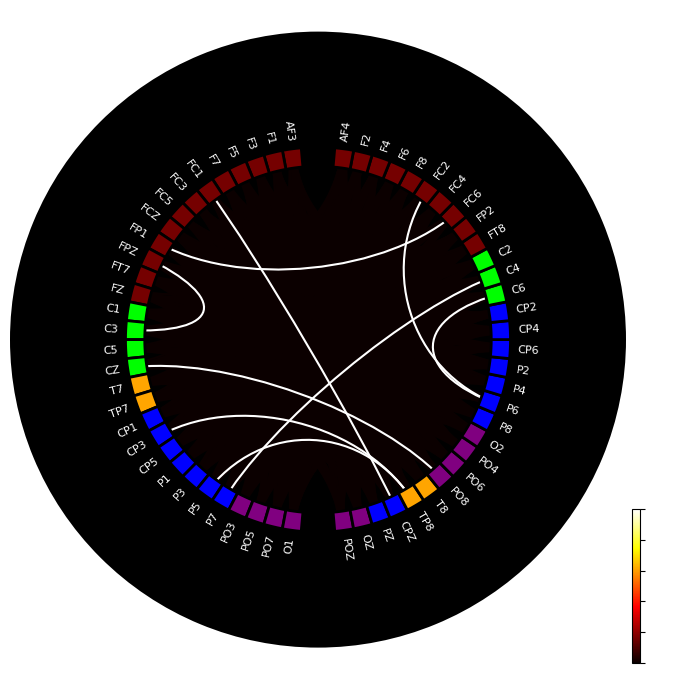


Top important connections in 1_120 Hz band:
1. CZ - PO8: 0.0007
2. P7 - C4: 0.0004
3. P5 - TP8: 0.0001
4. P6 - C6: 0.0006
5. FC1 - CPZ: 0.0013


In [ ]:
# Example notebook cell using the importance visualization

# Assuming you have run your analysis and have these variables:
for freq_band in hierarchy:
    X, y = process_connectivity_data(hierarchy, freq_band)
    scores, important_connections, importances = analyze_feature_importance(
        X, y, freq_band
    )

    # Create visualizations
    fig_single, fig_multi = visualize_all_importance(
        hierarchy, freq_band, important_connections, importances
    )
    plt.show()

    # Print top connections
    print(f"\nTop important connections in {freq_band} Hz band:")
    channel_names = get_channel_5_colors()
    for idx, (i, j) in enumerate(important_connections[:5]):
        print(
            f"{idx+1}. {channel_names[i]} - {channel_names[j]}: {importances[idx]:.4f}"
        )
